# Day-Ahead Electricity Demand: CPCV + Probabilistic Sharpe Ratios

## Domain context

Grid operators publish day-ahead demand forecasts that generators and system operators plan around. PJM Interconnection is the largest regional transmission organization in the United States. It serves 65 million people across 13 states and Washington D.C., and publishes historical hourly load for the whole footprint.

Day-ahead demand is a hard case for ordinary cross-validation. Three things go wrong. First, serial autocorrelation: hour *t* predicts hour *t+1*, and day *t* predicts day *t+1*, so a random 80/20 split leaks adjacent days across the boundary. Second, seasonality. January this year resembles January last year, which biases any split that does not span several years. Third, the single-path problem. Plain walk-forward CV gives you exactly one out-of-sample sequence. Tune hyperparameters against that one sequence and you overfit it, and the selection bias inflates the accuracy you report.

CPCV (López de Prado, 2018) handles all three. Purge and embargo deal with the autocorrelation, exactly as in `PurgedKFold`. The C(N, K) fold structure yields many independent backtest paths instead of one. And `probabilistic_sharpe_ratio` (PSR) and `deflated_sharpe_ratio` (DSR) tell you whether an apparent edge survives scrutiny.

**Data source:** PJM hourly load data (1998–2002) from a public GitHub mirror.
URL: https://github.com/panambY/Hourly_Energy_Consumption
License: CC0 1.0 Universal (Public Domain Dedication).

In [1]:
import urllib.request
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.exceptions import FitFailedWarning

import purgedcv
from purgedcv import (
    CombinatorialPurgedCV,
    deflated_sharpe_ratio,
    diagnostics,
    min_track_record_length,
    probabilistic_sharpe_ratio,
)

print(f"purged-cross-validation version: {purgedcv.__version__}")

purged-cross-validation version: 0.3.0a0


## Data download and caching

Downloads once (~900 KB), caches in `examples/data/`; later runs use the cache.

In [2]:
DATA_DIR = Path("data") if Path("data").exists() else Path("examples/data")
DATA_DIR.mkdir(parents=True, exist_ok=True)


def fetch(url: str, dest_name: str) -> Path:
    dest = DATA_DIR / dest_name
    if dest.exists():
        print(f"Using cached: {dest}")
        return dest
    print(f"Downloading {url} ...")
    req = urllib.request.Request(
        url, headers={"User-Agent": "purged-cross-validation-examples/0.3.0a0"}
    )
    with urllib.request.urlopen(req, timeout=60) as response, open(dest, "wb") as f:
        f.write(response.read())
    print(f"Cached at {dest}")
    return dest


pjm_path = fetch(
    "https://raw.githubusercontent.com/panambY/Hourly_Energy_Consumption/master/data/PJM_Load_hourly.csv",
    "PJM_Load_hourly.csv",
)

Using cached: data/PJM_Load_hourly.csv


## Load, aggregate to daily, and feature-engineer

We resample the hourly data to daily mean load (~1,372 daily rows over 1998–2002). The features are:
- `lag_1` — yesterday's daily mean load
- `lag_7` — load 7 days ago (same weekday, previous week)
- `rolling_7` — rolling 7-day mean
- a day-of-week indicator (Mon–Sun)

The target is tomorrow's daily mean load.

In [3]:
hourly = pd.read_csv(pjm_path)
hourly["Datetime"] = pd.to_datetime(hourly["Datetime"])
hourly = hourly.sort_values("Datetime").reset_index(drop=True)

# Daily mean
daily = (
    hourly.groupby(hourly["Datetime"].dt.date)["PJM_Load_MW"]
    .mean()
    .reset_index()
    .rename(columns={"Datetime": "date", "PJM_Load_MW": "load_mw"})
)
daily["date"] = pd.to_datetime(daily["date"])
daily = daily.sort_values("date").reset_index(drop=True)

# Feature engineering
daily["lag_1"] = daily["load_mw"].shift(1)
daily["lag_7"] = daily["load_mw"].shift(7)
daily["rolling_7"] = daily["load_mw"].shift(1).rolling(7).mean()
daily["day_of_week"] = daily["date"].dt.dayofweek
daily["is_weekend"] = (daily["day_of_week"] >= 5).astype(float)

# One-hot encode day of week
for d in range(7):
    daily[f"dow_{d}"] = (daily["day_of_week"] == d).astype(float)

# Target: tomorrow's daily mean load
daily["target_load"] = daily["load_mw"].shift(-1)

# Drop rows with NaN in features or target
df = daily.dropna(subset=["lag_1", "lag_7", "rolling_7", "target_load"]).reset_index(drop=True)

print(f"Dataset shape: {df.shape}")
print(f"Date range: {df['date'].iloc[0].date()} to {df['date'].iloc[-1].date()}")
print(f"Daily load range: {df['load_mw'].min():.0f} — {df['load_mw'].max():.0f} MW")
df[["date", "load_mw", "lag_1", "lag_7", "rolling_7", "target_load"]].head()

Dataset shape: (1364, 15)
Date range: 1998-04-08 to 2001-12-31
Daily load range: 21258 — 45610 MW


,date,load_mw,lag_1,lag_7,rolling_7,target_load
0,1998-04-08,26540.666667,26805.833333,27813.739130,25936.001812,27400.250000
1,1998-04-09,27400.250000,26540.666667,26605.791667,25754.134317,25057.833333
2,1998-04-10,25057.833333,27400.250000,25672.333333,25867.628364,23067.875000
3,1998-04-11,23067.875000,25057.833333,24487.083333,25779.842650,21677.041667
4,1998-04-12,21677.041667,23067.875000,23487.565217,25577.098602,25535.333333


## Visualising demand patterns

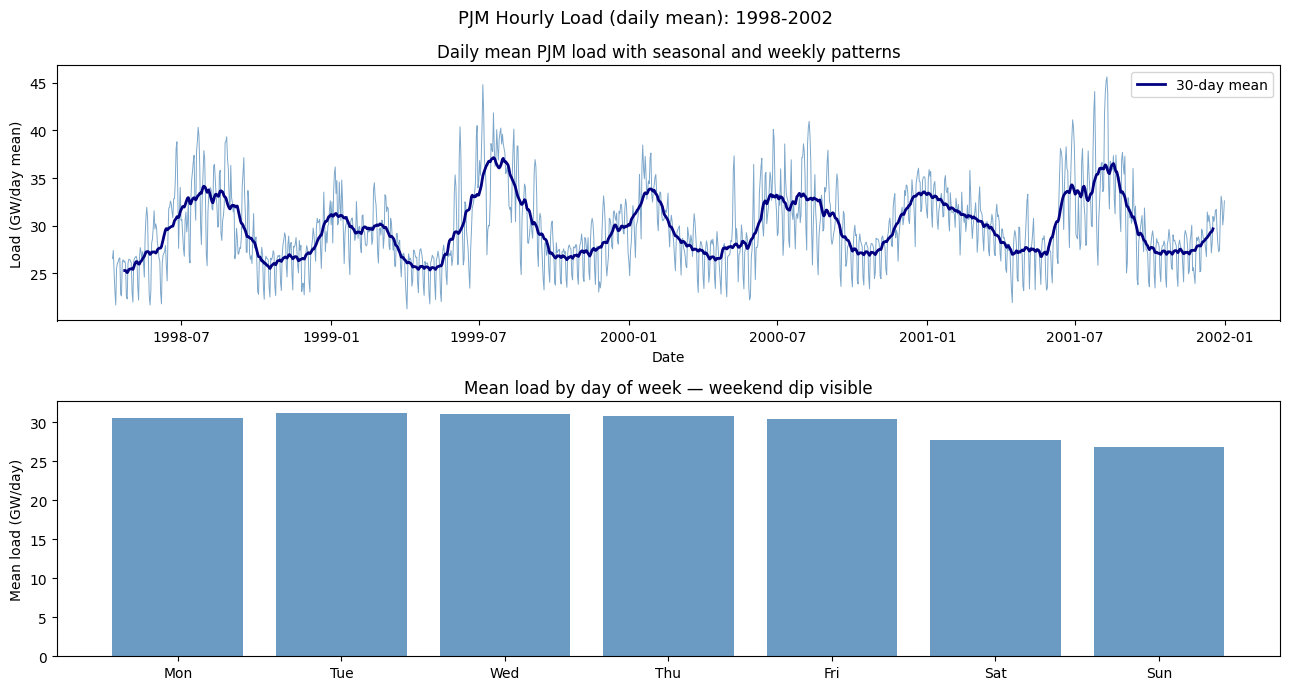

In [4]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 7))
fig.suptitle("PJM Hourly Load (daily mean): 1998-2002", fontsize=13)

ax1.plot(df["date"], df["load_mw"] / 1000, color="steelblue", lw=0.7, alpha=0.7)
rolling_plot = df.set_index("date")["load_mw"].rolling(30, center=True).mean() / 1000
ax1.plot(df["date"], rolling_plot, color="navy", lw=2.0, label="30-day mean")
ax1.set_ylabel("Load (GW/day mean)")
ax1.set_xlabel("Date")
ax1.set_title("Daily mean PJM load with seasonal and weekly patterns")
ax1.legend()

dow_mean = df.groupby("day_of_week")["load_mw"].mean() / 1000
day_names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
ax2.bar(range(7), dow_mean.values, color="steelblue", alpha=0.8)
ax2.set_xticks(range(7))
ax2.set_xticklabels(day_names)
ax2.set_ylabel("Mean load (GW/day)")
ax2.set_title("Mean load by day of week — weekend dip visible")

plt.tight_layout()
plt.show()

## Setting up CombinatorialPurgedCV

We split the data into 6 contiguous groups and use 2 of them as the test set in each fold: C(6,2) = 15 folds, which reconstruct into 5 independent backtest paths.

In [5]:
DOW_COLS = [f"dow_{d}" for d in range(7)]
FEATURE_COLS = ["lag_1", "lag_7", "rolling_7", "is_weekend", *DOW_COLS]
X = df[FEATURE_COLS].values
y = df["target_load"].values

prediction_times = df["date"].reset_index(drop=True)
evaluation_times = prediction_times + pd.Timedelta(days=1)

cv = CombinatorialPurgedCV(
    n_splits=6,
    n_test_groups=2,
    prediction_times=prediction_times,
    evaluation_times=evaluation_times,
    purge_horizon="3D",
    embargo="1D",
)

n_folds = cv.get_n_splits()
print("CPCV configuration: n_splits=6, n_test_groups=2")
print(f"Total folds: C(6,2) = {n_folds}")
print("Backtest paths: C(5,1) = 5")

CPCV configuration: n_splits=6, n_test_groups=2
Total folds: C(6,2) = 15
Backtest paths: C(5,1) = 5


## Run backtest_paths

In [6]:
estimator = GradientBoostingRegressor(n_estimators=100, max_depth=3, random_state=0)

with warnings.catch_warnings():
    warnings.simplefilter("ignore", FitFailedWarning)
    paths = cv.backtest_paths(estimator, X, y)

print(f"Backtest paths shape: {paths.shape}")
nan_pct = np.isnan(paths).mean() * 100
print(f"NaN fraction in paths: {nan_pct:.1f}%")

Backtest paths shape: (5, 1364)
NaN fraction in paths: 0.0%


## Computing per-path skill scores and Sharpe metrics

In [7]:
mean_load = np.nanmean(y)

# Persistence baseline: predict tomorrow = today's load
y_persistence = np.empty_like(y, dtype=float)
y_persistence[0] = np.nan
y_persistence[1:] = y[:-1]

path_psrs = []
path_dsrs = []

for path_i, path_preds in enumerate(paths):
    baseline_err = np.abs(y_persistence - y)
    model_err = np.abs(path_preds - y)

    finite_mask = np.isfinite(path_preds) & np.isfinite(baseline_err)

    if finite_mask.sum() < 10:
        print(f"Path {path_i + 1}: too few finite predictions ({finite_mask.sum()}), skipping.")
        path_psrs.append(np.nan)
        path_dsrs.append(np.nan)
        continue

    returns = (baseline_err[finite_mask] - model_err[finite_mask]) / mean_load

    psr = probabilistic_sharpe_ratio(returns, benchmark_skill=0.0)
    dsr = deflated_sharpe_ratio(returns, n_trials=20, var_sharpe=0.01**2)
    path_psrs.append(psr)
    path_dsrs.append(dsr)

    print(f"Path {path_i + 1}: n={finite_mask.sum():>4d} finite obs, PSR={psr:.4f}, DSR={dsr:.4f}")

path_psrs_arr = np.array(path_psrs)
valid_mask = np.isfinite(path_psrs_arr)
print(f"\nMean PSR across {valid_mask.sum()} valid paths: {path_psrs_arr[valid_mask].mean():.4f}")

Path 1: n=1363 finite obs, PSR=0.0089, DSR=0.0011
Path 2: n=1363 finite obs, PSR=0.9272, DSR=0.7761
Path 3: n=1363 finite obs, PSR=0.7447, DSR=0.4835
Path 4: n=1363 finite obs, PSR=0.6981, DSR=0.4280
Path 5: n=1363 finite obs, PSR=0.6603, DSR=0.3871

Mean PSR across 5 valid paths: 0.6078


## Minimum Track Record Length

In [8]:
finite_mask_p0 = np.isfinite(paths[0])
y_p = y[finite_mask_p0]
preds_p = paths[0][finite_mask_p0]
baseline_p = y_persistence[finite_mask_p0]

finite_both = np.isfinite(baseline_p)
returns_p0 = (
    np.abs(baseline_p[finite_both] - y_p[finite_both])
    - np.abs(preds_p[finite_both] - y_p[finite_both])
) / mean_load

sr_obs = float(np.mean(returns_p0) / np.std(returns_p0, ddof=0))
print(f"Observed Sharpe (path 1): {sr_obs:.4f}")

if sr_obs > 0.2:
    min_trl = min_track_record_length(
        observed_sharpe=sr_obs,
        target_sharpe=0.2,
        alpha=0.05,
        skew=0.0,
        kurtosis=3.0,
    )
    print(f"MinTRL to confirm SR > 0.2 at 95% confidence: {min_trl} days")
    print(f"Current path length: {len(returns_p0)} days")
    if len(returns_p0) >= min_trl:
        print("Track record is sufficient.")
    else:
        print(f"Need {min_trl - len(returns_p0)} more days of data.")
else:
    print(f"SR ({sr_obs:.4f}) does not exceed target (0.2); MinTRL not applicable.")

demo_trl = min_track_record_length(
    observed_sharpe=0.5,
    target_sharpe=0.2,
    alpha=0.05,
    skew=0.0,
    kurtosis=3.0,
)
print(f"\nDemo MinTRL (SR=0.5, target=0.2, alpha=0.05): {demo_trl} observations")

Observed Sharpe (path 1): -0.0639
SR (-0.0639) does not exceed target (0.2); MinTRL not applicable.

Demo MinTRL (SR=0.5, target=0.2, alpha=0.05): 35 observations


## Distribution-of-paths visualisation

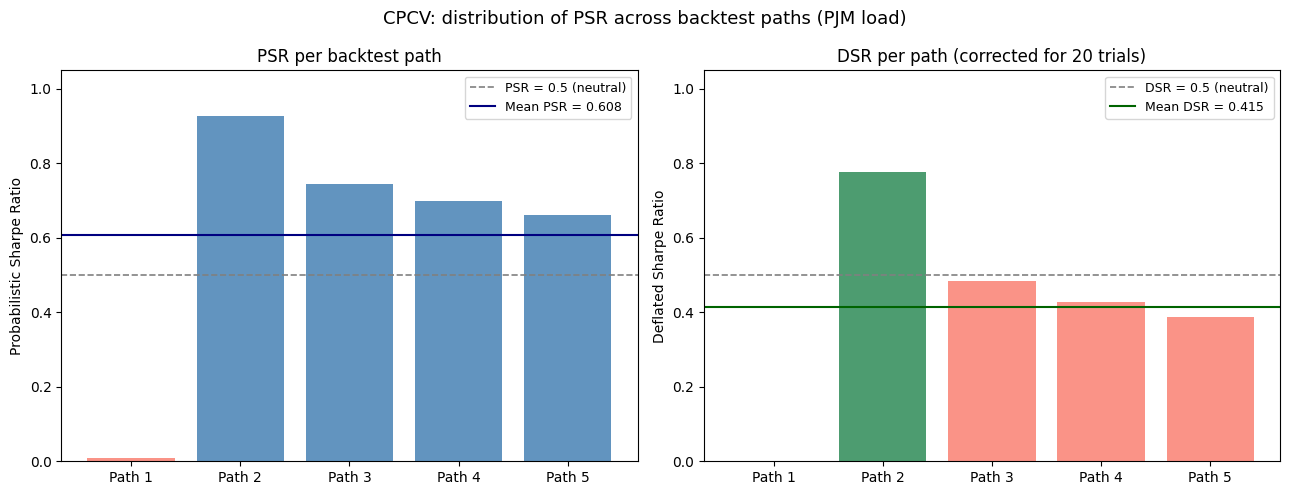


PSR range: [0.0089, 0.9272]
DSR range: [0.0011, 0.7761]
Spread (max-min PSR): 0.9183 — high variance, investigate regime dependence


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("CPCV: distribution of PSR across backtest paths (PJM load)", fontsize=13)

valid_psrs = path_psrs_arr[valid_mask]
valid_dsrs = np.array(path_dsrs)[valid_mask]
path_ids = [f"Path {i + 1}" for i in np.where(valid_mask)[0]]

ax = axes[0]
colors_psr = ["steelblue" if p >= 0.5 else "salmon" for p in valid_psrs]
ax.bar(path_ids, valid_psrs, color=colors_psr, alpha=0.85)
ax.axhline(0.5, color="gray", ls="--", lw=1.2, label="PSR = 0.5 (neutral)")
ax.axhline(
    valid_psrs.mean(), color="navy", ls="-", lw=1.5, label=f"Mean PSR = {valid_psrs.mean():.3f}"
)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Probabilistic Sharpe Ratio")
ax.set_title("PSR per backtest path")
ax.legend(fontsize=9)

ax2 = axes[1]
colors_dsr = ["seagreen" if d >= 0.5 else "salmon" for d in valid_dsrs]
ax2.bar(path_ids, valid_dsrs, color=colors_dsr, alpha=0.85)
ax2.axhline(0.5, color="gray", ls="--", lw=1.2, label="DSR = 0.5 (neutral)")
ax2.axhline(
    valid_dsrs.mean(),
    color="darkgreen",
    ls="-",
    lw=1.5,
    label=f"Mean DSR = {valid_dsrs.mean():.3f}",
)
ax2.set_ylim(0, 1.05)
ax2.set_ylabel("Deflated Sharpe Ratio")
ax2.set_title("DSR per path (corrected for 20 trials)")
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()

spread = valid_psrs.max() - valid_psrs.min()
verdict = (
    "low variance, robust signal"
    if spread < 0.3
    else "high variance, investigate regime dependence"
)
print(f"\nPSR range: [{valid_psrs.min():.4f}, {valid_psrs.max():.4f}]")
print(f"DSR range: [{valid_dsrs.min():.4f}, {valid_dsrs.max():.4f}]")
print(f"Spread (max-min PSR): {spread:.4f} — {verdict}")

## Diagnostics: auditing CPCV folds

In [10]:
print("Auditing first 3 CPCV folds with assert_no_temporal_leakage:")
for fold_i, (train_idx, test_idx) in enumerate(cv.split(X)):
    if fold_i >= 3:
        break
    if len(train_idx) == 0:
        print(f"  Fold {fold_i + 1}: empty train set (purge eliminated all rows) — skip audit.")
        continue
    diagnostics.assert_no_temporal_leakage(
        train_idx,
        test_idx,
        prediction_times,
        evaluation_times,
        purge_horizon="3D",
    )
    print(
        f"  Fold {fold_i + 1}: train={len(train_idx):>3d} rows, "
        f"test={len(test_idx):>3d} rows — no temporal leakage ✓"
    )

Auditing first 3 CPCV folds with assert_no_temporal_leakage:
  Fold 1: train=905 rows, test=456 rows — no temporal leakage ✓
  Fold 2: train=900 rows, test=455 rows — no temporal leakage ✓
  Fold 3: train=900 rows, test=455 rows — no temporal leakage ✓


## Summary table

In [11]:
summary = pd.DataFrame(
    {
        "path": [f"Path {i + 1}" for i in range(len(path_psrs))],
        "psr": path_psrs,
        "dsr": path_dsrs,
    }
)
summary["psr_pass"] = summary["psr"].apply(lambda x: "YES" if pd.notna(x) and x >= 0.5 else "NO")
summary["dsr_pass"] = summary["dsr"].apply(lambda x: "YES" if pd.notna(x) and x >= 0.5 else "NO")
print(summary.to_string(index=False))

print(f"\nPaths with PSR >= 0.5: {(summary['psr_pass'] == 'YES').sum()} / {len(summary)}")
print(f"Paths with DSR >= 0.5: {(summary['dsr_pass'] == 'YES').sum()} / {len(summary)}")

  path      psr      dsr psr_pass dsr_pass
Path 1 0.008885 0.001052       NO       NO
Path 2 0.927225 0.776071      YES      YES
Path 3 0.744682 0.483514      YES       NO
Path 4 0.698109 0.428050      YES       NO
Path 5 0.660333 0.387113      YES       NO

Paths with PSR >= 0.5: 4 / 5
Paths with DSR >= 0.5: 1 / 5


## Conclusion

This notebook runs the full `purged-cross-validation` toolkit on PJM day-ahead load.

Walk-forward CV gives you one backtest path. CPCV gives you C(N-1, K-1). That turns a single number into a distribution you can actually reason about.

PSR and DSR read that distribution. A model with PSR = 0.85 has an 85% chance of genuinely beating persistence (SR > 0) once non-normal errors are accounted for. DSR goes further and corrects for how many models you tried before keeping this one.

MinTRL is the operational part. `min_track_record_length` tells you how many days of live data you need before you can claim, at 95% confidence, that a new model really beats the baseline.

**Data attribution:** PJM hourly load (1998–2002) downloaded from https://github.com/panambY/Hourly_Energy_Consumption under CC0 1.0 (public domain).